# Gradient Descent

<img src="./img/3_GD.png" width="500px">
<br><br>

### Def: Gradient Descent

> &nbsp;  
> In mathematics, `gradient descent` (also often called steepest descent) is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function. 
>
> The idea is to take repeated steps in the opposite direction of the gradient (or approximate gradient) of the function at the current point, because this is the direction of steepest descent.  
> Conversely, stepping in the direction of the gradient will lead to a local maximum of that function; the procedure is then known as gradient ascent.
> <br><br>

<span style="font-size: 70%">Source: <a href="https://en.wikipedia.org/wiki/Gradient_descent">Wikipedia - Gradient descent</a></span>


### Motivation

Assume a dataset we want to find a formula that best describes this data.

- define a __hypothesis__ (parameterized formula) that approximates the data
- __adjust parameters__ to optimally represent the data

<br>

How do we know which parameters are __optimal__?  
How can we __change parameters__?  
How do we __implement__ this into __code__?  

<br>

### Example: A simple linear regression

<img src="./img/3_GD_LR_approximation.png" width="500px"><br><br>
<span style="font-size: 70%">Figure 1: Data that is represented by a formula with differently suited parameters. <br>Some parameters work better than others. Gradient descent will find an optimal set.</span>

##### 1. Hypothesis

We can approximate data as:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$ h_\theta = \theta_0 + \theta_1 \cdot X $  

$\theta_0, \theta_1$ ... need changing

##### 2. Error of approximation

Our approximation is erroneous:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$ E = \left ( h_\theta \left ( x_i\right ) - y_i \right ) $

with $y_i$ being the exact value in the data set

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$ MSE = \frac {1}{m} \sum_{i=0}^{m} \color{blue}{ \left ( h_\theta \left ( x_i\right ) - y_i \right ) } \color{#606060}^2 $

##### 3. Cost function

$ J \left ( \theta_0, \theta_1 \right) = \frac {\color{blue}{1}}{2 \cdot \color{blue}{m}} \color{blue}{ \sum_{i=0}^{m}  \left ( h_\theta \left ( x_i\right ) - y_i \right ) } \color{gray}^2 $

Change $\theta_0, \theta_1$ until $J \left ( \theta_0, \theta_1 \right)$ is minimum

##### Proceed as

> &nbsp;  
> 1. randomly initialize $\theta_0, \theta_1$<br><br>
> 2. update values $\theta_0, \theta_1$:<br><br>
> &nbsp;&nbsp;&nbsp;$ \theta_j = \theta_j - \alpha \cdot \color{blue}{\frac{\partial J\left ( \theta_j \right )}{\partial \theta_j}} $<br><br>
> 3. repeat 2. until $ \frac{\partial J\left ( \theta_j \right )}{\partial \theta_j} \to 0 $ (or close to $0$)<br><br>

$\alpha$ ... Learning rate, &nbsp;$ \frac{\partial J\left ( \theta_j \right )}{\partial \theta_j} $ ... Gradient 

Let's do some coding

In [1]:
# the ubiquitous imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# prepare the data

x = np.array([1, 1.5, 2.1, 2.5, 3])
y = np.array([1.2, 1.4, 2.2, 2.6, 2.9])

# some estimates
y1 = np.array([1, 1.5, 2.1, 2.5, 3])
xr = np.array([0, 3.2])
yr1 = np.array([0, 3.2])
yr2 = np.array([0, 1.6])
yr3 = np.array([.5, 2.95])

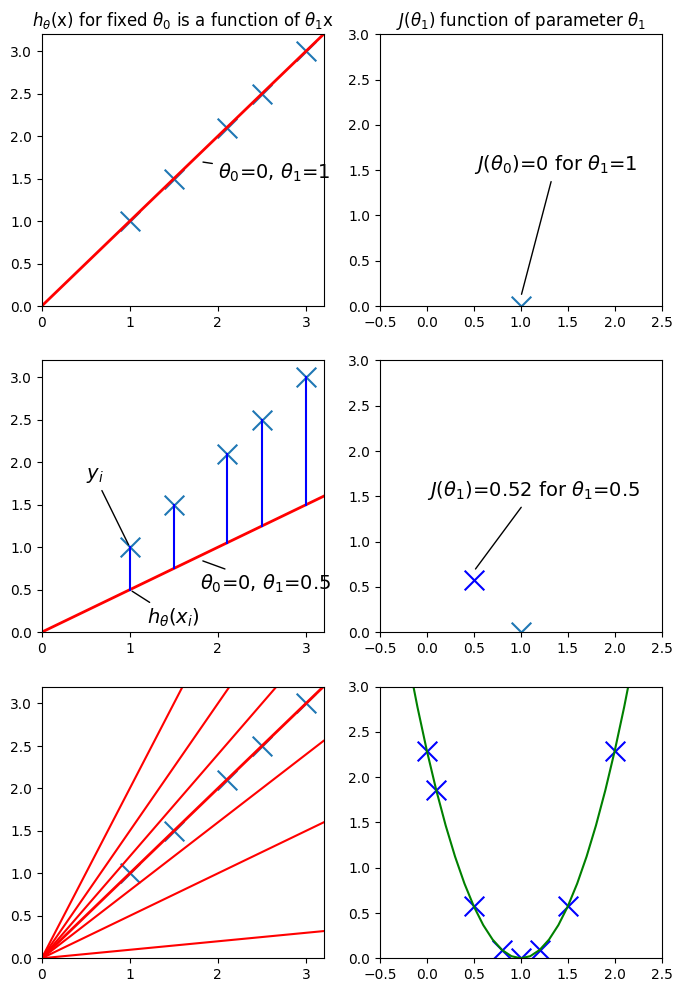

In [3]:
# visualize data (left) and cost function (errors, right)

fig = plt.figure(figsize=(8, 12))

# linear best fit
plt.subplot(3, 2, 1)
plt.title(r'$h_\theta$(x) for fixed $\theta_0$ is a function of $\theta_1$x')
plt.scatter(x, y1, marker='x', s=200)
plt.plot(xr, yr1, c='red', linewidth=2)
plt.xlim((0, 3.2))
plt.ylim((0, 3.2))
plt.annotate(r'$\theta_0$=0, $\theta_1$=1',
             xy=(1.8, 1.7), xytext=(2.0, 1.5),
             arrowprops=dict(arrowstyle='-'),
             fontsize=14)

# cost best fit
plt.subplot(3, 2, 2)
plt.title(r'$J(\theta_1)$ function of parameter $\theta_1$')
theta_1 = 1.0
J_theta = 1/(2*len(y1))*sum((y1 - y1 * theta_1) ** 2)
plt.scatter(theta_1, J_theta, marker='x', s=200)
plt.xlim((-0.5, 2.5))
plt.ylim((0, 3))
plt.annotate(r'$J(\theta_0)$=0 for $\theta_1$=1',
             xy=(1.0, 0.1), xytext=(0.5, 1.5),
             arrowprops=dict(arrowstyle='-'),
             fontsize=14)

# LR with theta_1 = 0.5
plt.subplot(3, 2, 3)
plt.scatter(x, y1, marker='x', s=200)
plt.plot(xr, yr2, c='red', linewidth=2)
plt.xlim((0, 3.2))
plt.ylim((0, 3.2))
plt.annotate(r'$\theta_0$=0, $\theta_1$=0.5',
             xy=(1.8, 0.85), xytext=(1.8, 0.5),
             arrowprops=dict(arrowstyle='-'),
             fontsize=14)

plt.plot([1, 1], [0.5, 1], c='blue')
plt.plot([1.5, 1.5], [0.75, 1.5], c='blue')
plt.plot([2.1, 2.1], [1.05, 2.1], c='blue')
plt.plot([2.5, 2.5], [1.25, 2.5], c='blue')
plt.plot([3.0, 3.0], [1.5, 3.0], c='blue')
plt.annotate(r'$h_\theta(x_i)$',
             xy=(1.0, 0.5), xytext=(1.2, 0.1),
             arrowprops=dict(arrowstyle='-'),
             fontsize=14)
plt.annotate(r'$y_i$',
             xy=(1.0, 1.0), xytext=(.5, 1.8),
             arrowprops=dict(arrowstyle='-'),
             fontsize=14)

# cost for theta_1 = 0.5
plt.subplot(3, 2, 4)
theta_1 = 0.5
J_theta = 1/(2*len(y1))*sum((y1 - y1 * theta_1) ** 2)
plt.scatter(1, 0, marker='x', s=200)
plt.scatter(theta_1, J_theta, marker='x', s=200, c='blue')
plt.xlim((-0.5, 2.5))
plt.ylim((0, 3))
plt.annotate(r'$J(\theta_1)$=0.52 for $\theta_1$=0.5',
             xy=(theta_1, J_theta + 0.1), xytext=(0.0, 1.5),
             arrowprops=dict(arrowstyle='-'),
             fontsize=14)

# cummulated LR charges
plt.subplot(3, 2, 5)
# plt.title(r'$h_\theta$(x) for fixed $\theta_0$ is a function of $\theta_1$x')
plt.scatter(x, y1, marker='x', s=200)
plt.plot(xr, yr1, c='red', linewidth=2)
plt.plot(xr, yr2, c='red')
plt.plot(xr, yr1*.1, c='red')
plt.plot(xr, yr1*.8, c='red')
plt.plot(xr, yr1*1.2, c='red')
plt.plot(xr, yr1*1.5, c='red')
plt.plot(xr, yr1*2.0, c='red')

plt.xlim((0, 3.2))
plt.ylim((0, 3.2))

plt.subplot(3, 2, 6)
for theta_1 in [0.0, 0.1, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    J_theta = 1/(2*len(y1))*sum((y1 - y1 * theta_1) ** 2)
    plt.scatter(theta_1, J_theta, marker='x', s=200, c='blue')

# draw cost function
theta_iterate = np.arange(-0.5, 2.5, 0.1)
J_theta_iterate = [1/(2*len(y1))*sum((y1 - y1 * x)**2) for x in theta_iterate]
plt.plot(theta_iterate, J_theta_iterate, c='green')

plt.xlim((-0.5, 2.5))
plt.ylim((0, 3))

#plt.savefig('./img/3_lr_discussion_01.png', format='png', pad_inches=0.0)
plt.show()


Different $\theta_j$ result in a (quadratic $^*$) loss function.

<span style="font-size: 70%">*) in Linear regressions</span>


##### Optimum

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$ \lim_{m}  {\frac{\partial J\left ( \theta_j \right )}{\partial \theta_j}}\to 0 $


##### Maths for Linear Regression

<img src="./img/3_GD_maths.png" width="1000px">

$\alpha$ ... Learning rate (or step size)

### Learning rate

The learning rate impacts convergence of `Gradient descent`.

<img src="./img/3_SGD_convergence.gif" width="700px"><br>
<span style="font-size: 70%">Figure 2: A <b>small</b> learning rate will make GD slow. If the learning rate is <b>large</b> the algorithm might not converge at all.</span>
<br><br>


There are several strategies to improve convergence:

- fixed small learning rate (test experimentally)
- shrink learning rate over time (might get caught in local minima)
- adjust step size so that cost function gets minimized (higher computational cost)

Others include:

- batches / mini batches to compute CG
- boosting algorithms


<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Chapter 8 (p 139ff) from "Data Science from Scratch"</li>
<li><a href="https://scikit-learn.org/stable/modules/sgd.html">Scikit-Learn on Stochastic Gradient Descent</a></li>
<li>specifically the <a href="https://scikit-learn.org/stable/modules/sgd.html#mathematical-formulation">mathematical formulation</a></li>
</ul>
</td>
</tr>
</table>

<span style="font-size: 128px">&#9749;</span> Coffee break!